# Trigonometric Functions — Lecture 9
## Practice Session: Cracking Problems with Trigonometric Formulae

**Source:** [Trigonometric Functions 09 | Practice Session | Crack Best Problems with Trigonometric Formulae](https://www.youtube.com/watch?v=CGB8ZP0Xc2E), Physics Wallah (Class 11), about 52 min

**Prerequisite:** every formula from Lectures 4–8. The lecturer's warning: *"if you haven't memorised the formulae, memorise them first, then attempt these."*

> *"Trigonometry is calling you, so don't be scared to go. Just don't go home empty-handed: take all the formulae with you."*

### Problems in this lecture
1. $\sin\alpha\,\sin(60^\circ - \alpha)\,\sin(60^\circ + \alpha) = \frac14\sin 3\alpha$, plus its $\cos$ and $\tan$ siblings
2. Given $\sin\theta + \sin\phi = a$ and $\cos\theta + \cos\phi = b$, find $\tan\frac{\theta+\phi}{2}$ and $\tan\frac{\theta-\phi}{2}$
3. $(\cos\alpha + \cos\beta)^2 + (\sin\alpha - \sin\beta)^2 = 4\cos^2\frac{\alpha+\beta}{2}$
4. $\cos\frac{\pi}{15}\cos\frac{2\pi}{15}\cos\frac{3\pi}{15}\cdots\cos\frac{7\pi}{15} = \frac{1}{2^7}$, the "doubling-angle cosine product"
5. $\sqrt3\csc 20^\circ - \sec 20^\circ = 4$
6. Homework: $\sin 18^\circ = \frac{\sqrt5 - 1}{4}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle

# Same look as the earlier lectures
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
d = np.deg2rad
rng = np.random.default_rng(9)

def verify(name, lhs, rhs):
    ok = np.isfinite(lhs) & np.isfinite(rhs) & (np.abs(lhs) < 1e6)
    good = np.isclose(lhs[ok], rhs[ok], rtol=1e-6, atol=1e-9)
    print(f"{name:<52} {good.mean()*100:6.2f}% of {ok.sum():,} samples agree")

def broken(y, jump=8):
    y = np.array(y, dtype=float); y[np.abs(np.diff(np.r_[y[0], y])) > jump] = np.nan; return y
print("ready")

ready


---
## Q1. Prove $\sin\alpha\,\sin(60^\circ - \alpha)\,\sin(60^\circ + \alpha) = \frac14\sin 3\alpha$

**Spot the pattern:** $\sin(60^\circ - \alpha)\sin(60^\circ + \alpha)$ has the form $\sin(A - B)\sin(A + B)$. From Lecture 5, that equals $\sin^2A - \sin^2B$:
$$\text{LHS} = \sin\alpha\left(\sin^2 60^\circ - \sin^2\alpha\right) = \sin\alpha\left(\frac34 - \sin^2\alpha\right)$$
Take $\frac14$ out:
$$= \frac14\left(3\sin\alpha - 4\sin^3\alpha\right) = \frac14\sin 3\alpha \quad\blacksquare$$
using $\sin 3\alpha = 3\sin\alpha - 4\sin^3\alpha$ from Lecture 8.

### Two siblings (homework from the lecture; "about 5 minutes")
$$\cos\alpha\,\cos(60^\circ - \alpha)\,\cos(60^\circ + \alpha) = \frac14\cos 3\alpha$$
$$\tan\alpha\,\tan(60^\circ - \alpha)\,\tan(60^\circ + \alpha) = \tan 3\alpha$$

<details>
<summary>Hints</summary>

- $\cos(A-B)\cos(A+B) = \cos^2A - \sin^2B$, so the $\cos$ product is $\cos\alpha\left(\frac14 - \sin^2\alpha\right) = \cos\alpha\left(\cos^2\alpha - \frac34\right) = \frac14(4\cos^3\alpha - 3\cos\alpha)$.
- Divide the $\sin$ result by the $\cos$ result to get the $\tan$ result.
</details>

These three results are the reason Lecture 8's practice question 4 worked.

sinα sin(60°−α) sin(60°+α) = ¼ sin3α                 100.00% of 100,000 samples agree
cosα cos(60°−α) cos(60°+α) = ¼ cos3α                 100.00% of 100,000 samples agree
tanα tan(60°−α) tan(60°+α) = tan3α                   100.00% of 100,000 samples agree


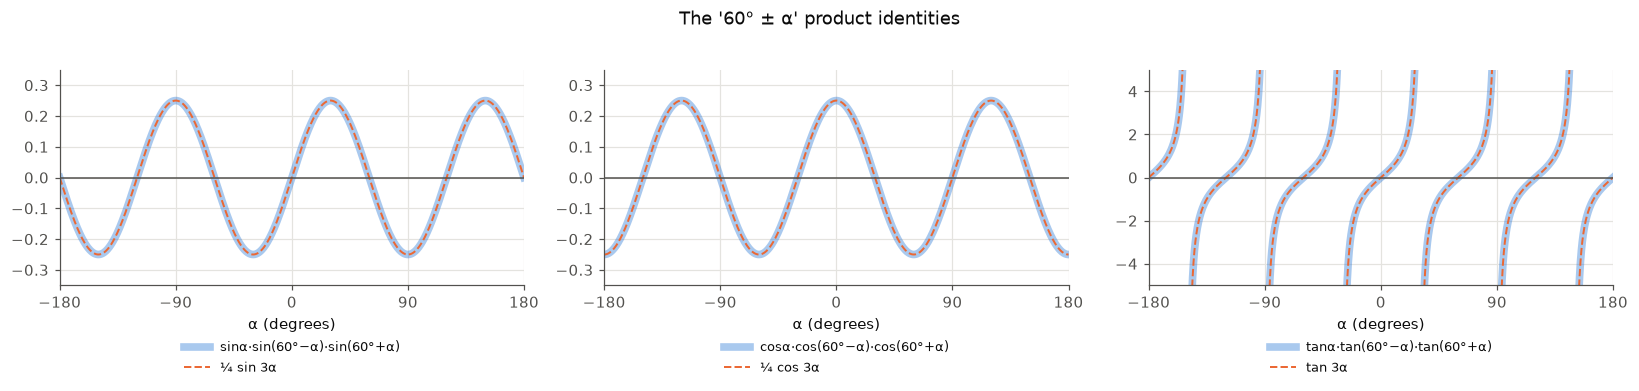

In [2]:
a = rng.uniform(-3, 3, 100_000); s60 = d(60)
verify("sinα sin(60°−α) sin(60°+α) = ¼ sin3α", np.sin(a)*np.sin(s60 - a)*np.sin(s60 + a), np.sin(3*a)/4)
verify("cosα cos(60°−α) cos(60°+α) = ¼ cos3α", np.cos(a)*np.cos(s60 - a)*np.cos(s60 + a), np.cos(3*a)/4)
verify("tanα tan(60°−α) tan(60°+α) = tan3α",   np.tan(a)*np.tan(s60 - a)*np.tan(s60 + a), np.tan(3*a))

x = np.linspace(-180, 180, 2000); xr = d(x)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, f, rhs, name, rname in [
        (axes[0], np.sin, np.sin(3*xr)/4, "sin", "¼ sin 3α"),
        (axes[1], np.cos, np.cos(3*xr)/4, "cos", "¼ cos 3α"),
        (axes[2], np.tan, np.tan(3*xr), "tan", "tan 3α")]:
    lhs = f(xr)*f(s60 - xr)*f(s60 + xr)
    ax.plot(x, broken(lhs), color=BLUE, lw=5, alpha=0.4, label=f"{name}α·{name}(60°−α)·{name}(60°+α)")
    ax.plot(x, broken(rhs), color=ORANGE, lw=1.3, ls="--", label=rname)
    ax.axhline(0, color=INK2, lw=1); ax.set_xticks(range(-180, 181, 90)); ax.set_xlim(-180, 180)
    ax.set_ylim(*((-0.35, 0.35) if name != "tan" else (-5, 5))); ax.set_xlabel("α (degrees)")
    ax.legend(frameon=False, ncol=1, loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=8.5)
fig.suptitle("The '60° ± α' product identities", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

---
## Q2. If $\sin\theta + \sin\phi = a$ and $\cos\theta + \cos\phi = b$, find $\tan\frac{\theta+\phi}{2}$ and $\tan\frac{\theta-\phi}{2}$

### Part (i): $\tan\frac{\theta+\phi}{2}$ by C & D, then divide
$$\sin\theta + \sin\phi = 2\sin\tfrac{\theta+\phi}{2}\cos\tfrac{\theta-\phi}{2} = a \qquad (1)$$
$$\cos\theta + \cos\phi = 2\cos\tfrac{\theta+\phi}{2}\cos\tfrac{\theta-\phi}{2} = b \qquad (2)$$
Divide $(1)$ by $(2)$. The factors $2\cos\frac{\theta-\phi}{2}$ cancel:
$$\boxed{\tan\frac{\theta+\phi}{2} = \frac{a}{b}}$$

### Part (ii): $\tan\frac{\theta-\phi}{2}$ by squaring and adding
Square and add the original equations:
$$(\sin^2\theta + \cos^2\theta) + (\sin^2\phi + \cos^2\phi) + 2(\cos\theta\cos\phi + \sin\theta\sin\phi) = a^2 + b^2$$
$$2 + 2\cos(\theta - \phi) = a^2 + b^2 \;\Longrightarrow\; \cos(\theta - \phi) = \frac{a^2 + b^2 - 2}{2}$$

**Power reduction in "masala" form (Lecture 8):** $\tan^2\frac{x}{2} = \dfrac{1 - \cos x}{1 + \cos x}$. With $x = \theta - \phi$:
$$\tan^2\frac{\theta - \phi}{2} = \frac{1 - \frac{a^2 + b^2 - 2}{2}}{1 + \frac{a^2 + b^2 - 2}{2}} = \frac{4 - a^2 - b^2}{a^2 + b^2}$$
$$\boxed{\tan\frac{\theta - \phi}{2} = \pm\sqrt{\frac{4 - a^2 - b^2}{a^2 + b^2}}}$$
The $\pm$ appears because we took a square root. Without more information about the angles, the sign can't be fixed.

In [3]:
th, ph = rng.uniform(-np.pi, np.pi, (2, 100_000))
A = np.sin(th) + np.sin(ph); B = np.cos(th) + np.cos(ph)
verify("tan((θ+φ)/2) = a/b", np.tan((th + ph)/2), A/B)
verify("tan²((θ−φ)/2) = (4 − a² − b²)/(a² + b²)", np.tan((th - ph)/2)**2, (4 - A**2 - B**2)/(A**2 + B**2))

tan((θ+φ)/2) = a/b                                   100.00% of 100,000 samples agree
tan²((θ−φ)/2) = (4 − a² − b²)/(a² + b²)              100.00% of 99,943 samples agree


### Why this works: a picture *(extra)*
Put the two angles on the unit circle as points $P = (\cos\theta, \sin\theta)$ and $Q = (\cos\phi, \sin\phi)$. Their **vector sum** is exactly $(b, a)$.

- $OP$ and $OQ$ both have length 1, so $O, P, P+Q, Q$ form a **rhombus**. Its diagonal $O \to P+Q$ **bisects** the angle between them, so it points in the direction $\frac{\theta+\phi}{2}$. Hence $\tan\frac{\theta+\phi}{2} = \frac{a}{b}$.
- The diagonal's length is $2\cos\frac{\theta-\phi}{2}$, so $a^2 + b^2 = 4\cos^2\frac{\theta-\phi}{2}$. That is the same as $2 + 2\cos(\theta - \phi)$.

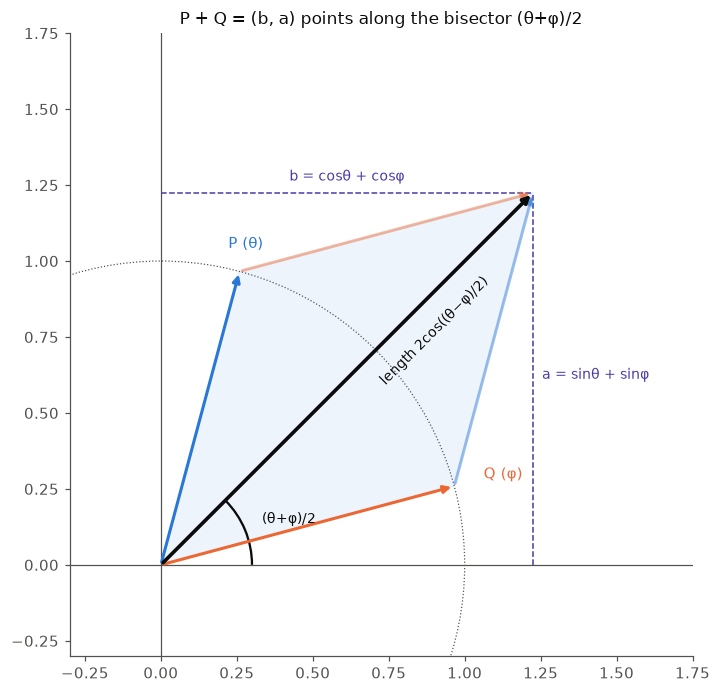

atan2(a, b) = 45.0000°   (θ+φ)/2 = 45.0000°
|P+Q| = 1.732051   2cos((θ−φ)/2) = 1.732051


In [4]:
th0, ph0 = d(75), d(15)
P = np.array([np.cos(th0), np.sin(th0)]); Q = np.array([np.cos(ph0), np.sin(ph0)]); S = P + Q
fig, ax = plt.subplots(figsize=(6.8, 6.4)); ax.set_aspect("equal"); ax.grid(False)
ax.add_patch(Circle((0, 0), 1, fill=False, ec=INK2, lw=0.8, ls=":"))
ax.axhline(0, color=INK2, lw=0.8); ax.axvline(0, color=INK2, lw=0.8)
ax.fill([0, P[0], S[0], Q[0]], [0, P[1], S[1], Q[1]], color=BLUE, alpha=0.08)
for (u, v, col, al) in [((0, 0), P, BLUE, 1), ((0, 0), Q, ORANGE, 1), (P, S, ORANGE, 0.45), (Q, S, BLUE, 0.45)]:
    ax.annotate("", xy=tuple(v), xytext=tuple(u), arrowprops=dict(arrowstyle="-|>", color=col, lw=2, alpha=al))
ax.annotate("", xy=S, xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color=INK, lw=2.4))
ax.plot([S[0], S[0]], [0, S[1]], color=VIOLET, lw=1, ls="--"); ax.plot([0, S[0]], [S[1], S[1]], color=VIOLET, lw=1, ls="--")
ax.text(S[0] + 0.03, S[1]/2, "a = sinθ + sinφ", color=VIOLET, fontsize=9)
ax.text(S[0]/2, S[1] + 0.04, "b = cosθ + cosφ", color=VIOLET, fontsize=9, ha="center")
ax.text(*(P*1.08), "P (θ)", color=BLUE, fontsize=10, ha="center"); ax.text(*(Q*1.1), "Q (φ)", color=ORANGE, fontsize=10)
mid = (th0 + ph0)/2
ax.add_patch(Arc((0, 0), 0.6, 0.6, theta1=0, theta2=np.rad2deg(mid), color=INK, lw=1.5))
ax.text(0.36*np.cos(mid/2), 0.36*np.sin(mid/2), "(θ+φ)/2", fontsize=9)
ax.text(S[0]*0.55 + 0.04, S[1]*0.55 - 0.08, "length 2cos((θ−φ)/2)", fontsize=9, rotation=np.rad2deg(mid))
ax.set_xlim(-0.3, 1.75); ax.set_ylim(-0.3, 1.75)
ax.set_title("P + Q = (b, a) points along the bisector (θ+φ)/2", fontsize=11)
plt.tight_layout(); plt.show()
print(f"atan2(a, b) = {np.rad2deg(np.arctan2(S[1], S[0])):.4f}°   (θ+φ)/2 = {np.rad2deg(mid):.4f}°")
print(f"|P+Q| = {np.hypot(*S):.6f}   2cos((θ−φ)/2) = {2*np.cos((th0 - ph0)/2):.6f}")

---
## Q3. Prove $(\cos\alpha + \cos\beta)^2 + (\sin\alpha - \sin\beta)^2 = 4\cos^2\frac{\alpha+\beta}{2}$

Open both squares:
$$\cos^2\alpha + \cos^2\beta + 2\cos\alpha\cos\beta + \sin^2\alpha + \sin^2\beta - 2\sin\alpha\sin\beta$$
Pair $\sin^2 + \cos^2$ for each angle. Each pair is $1$, and $2$ is common to the rest:
$$= 2 + 2(\cos\alpha\cos\beta - \sin\alpha\sin\beta) = 2 + 2\cos(\alpha + \beta) = 2\big(1 + \cos(\alpha+\beta)\big)$$

**Lecture 8, masala form:** $1 + \cos(\text{m}) = 2\cos^2\frac{\text{m}}{2}$. So
$$= 2\cdot 2\cos^2\frac{\alpha + \beta}{2} = 4\cos^2\frac{\alpha+\beta}{2} \quad\blacksquare$$

> **Lesson:** "intuition for formulas comes with practice." Spot $1 + \cos(\cdot)$ and think $2\cos^2(\cdot/2)$ immediately.

In [5]:
al, be = rng.uniform(-np.pi, np.pi, (2, 100_000))
verify("(cosα + cosβ)² + (sinα − sinβ)² = 4cos²((α+β)/2)",
       (np.cos(al) + np.cos(be))**2 + (np.sin(al) - np.sin(be))**2, 4*np.cos((al + be)/2)**2)

(cosα + cosβ)² + (sinα − sinβ)² = 4cos²((α+β)/2)     100.00% of 100,000 samples agree


---
## Q4. Prove $\cos\frac{\pi}{15}\cos\frac{2\pi}{15}\cos\frac{3\pi}{15}\cos\frac{4\pi}{15}\cos\frac{5\pi}{15}\cos\frac{6\pi}{15}\cos\frac{7\pi}{15} = \frac{1}{2^7}$

**Step 1: sort the seven factors into two buckets.**
- **Bucket A (angles that double):** $\cos\frac{\pi}{15}, \cos\frac{2\pi}{15}, \cos\frac{4\pi}{15}$, and $\cos\frac{7\pi}{15}$ rewritten so that it continues the doubling pattern ($\frac{8\pi}{15}$).
- **Bucket B (the rest):** $\cos\frac{3\pi}{15} = \cos\frac{\pi}{5}$, $\cos\frac{6\pi}{15} = \cos\frac{2\pi}{5}$, and $\cos\frac{5\pi}{15} = \cos\frac{\pi}{3} = \frac12$.

**Step 2: make bucket A double cleanly.** $\frac{7\pi}{15} = \pi - \frac{8\pi}{15}$, and $\cos(\pi - x) = -\cos x$ (quadrant II), so
$$\cos\frac{7\pi}{15} = -\cos\frac{8\pi}{15}$$

### The key technique: the doubling-angle cosine product
> **When $\cos$ factors are multiplied and each angle is double the previous one, multiply the top and bottom by $2\sin(\text{smallest angle})$. Then apply $2\sin x\cos x = \sin 2x$ over and over, and the product collapses.**

$$\cos A\cos 2A\cos 4A\cdots\cos 2^{n-1}A = \frac{\sin 2^n A}{2^n\sin A}$$

Each multiplication by 2 creates one more $2\sin(\cdot)\cos(\cdot) = \sin(2\,\cdot)$, which feeds into the next factor.

**Bucket A**, with $A = \frac{\pi}{15}$ and $n = 4$:
$$\cos\frac{\pi}{15}\cos\frac{2\pi}{15}\cos\frac{4\pi}{15}\cos\frac{8\pi}{15} = \frac{\sin\frac{16\pi}{15}}{16\sin\frac{\pi}{15}} = \frac{-\sin\frac{\pi}{15}}{16\sin\frac{\pi}{15}} = -\frac{1}{16}$$
(because $\sin\left(\pi + \frac{\pi}{15}\right) = -\sin\frac{\pi}{15}$, quadrant III). Together with the minus sign from Step 2, bucket A gives $+\frac{1}{16}$.

**Bucket B**, with $A = \frac{\pi}{5}$ and $n = 2$:
$$\cos\frac{\pi}{5}\cos\frac{2\pi}{5} = \frac{\sin\frac{4\pi}{5}}{4\sin\frac{\pi}{5}} = \frac{\sin\frac{\pi}{5}}{4\sin\frac{\pi}{5}} = \frac14, \qquad \cos\frac{\pi}{3} = \frac12$$

**Multiply the buckets:**
$$\frac{1}{16}\cdot\frac14\cdot\frac12 = \frac{1}{128} = \frac{1}{2^7} \quad\blacksquare$$

In [6]:
k = np.arange(1, 8)
prod = np.prod(np.cos(k*np.pi/15))
print(f"∏ cos(kπ/15), k = 1…7 = {prod:.12f}   1/2⁷ = {1/2**7:.12f}")
bucketA = np.cos(np.pi/15)*np.cos(2*np.pi/15)*np.cos(4*np.pi/15)*np.cos(7*np.pi/15)
bucketB = np.cos(3*np.pi/15)*np.cos(6*np.pi/15)*np.cos(5*np.pi/15)
print(f"bucket A = {bucketA:.6f} (1/16 = {1/16}),  bucket B = {bucketB:.6f} (1/8 = {1/8})")

# The general doubling identity, checked for n = 1…6
Av = rng.uniform(0.05, 1.5, 20_000)
for n in range(1, 7):
    lhs = np.prod([np.cos(2**j*Av) for j in range(n)], axis=0)
    verify(f"cosA·cos2A·…·cos2^{n-1}A = sin(2^{n}A)/(2^{n} sinA)", lhs, np.sin(2**n*Av)/(2**n*np.sin(Av)))

∏ cos(kπ/15), k = 1…7 = 0.007812500000   1/2⁷ = 0.007812500000
bucket A = 0.062500 (1/16 = 0.0625),  bucket B = 0.125000 (1/8 = 0.125)
cosA·cos2A·…·cos2^0A = sin(2^1A)/(2^1 sinA)          100.00% of 20,000 samples agree
cosA·cos2A·…·cos2^1A = sin(2^2A)/(2^2 sinA)          100.00% of 20,000 samples agree
cosA·cos2A·…·cos2^2A = sin(2^3A)/(2^3 sinA)          100.00% of 20,000 samples agree
cosA·cos2A·…·cos2^3A = sin(2^4A)/(2^4 sinA)          100.00% of 20,000 samples agree
cosA·cos2A·…·cos2^4A = sin(2^5A)/(2^5 sinA)          100.00% of 20,000 samples agree
cosA·cos2A·…·cos2^5A = sin(2^6A)/(2^6 sinA)          100.00% of 20,000 samples agree


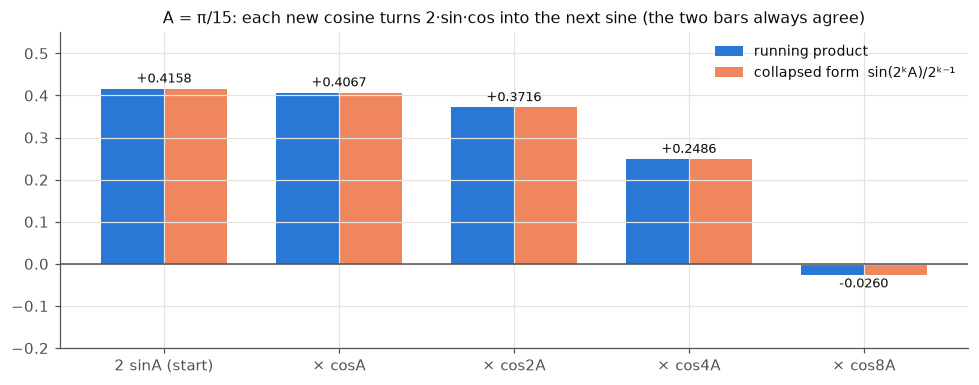

In [7]:
# Watch the product collapse: after multiplying by 2 sinA, each step is just sin(2^k A)/2^k.
A0 = np.pi/15
steps = ["2 sinA (start)", "× cosA", "× cos2A", "× cos4A", "× cos8A"]
running = [2*np.sin(A0)]
for j in range(4):
    running.append(running[-1]*np.cos(2**j*A0))
collapsed = [2*np.sin(A0)] + [np.sin(2**(j + 1)*A0)/2**j for j in range(4)]
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(np.arange(5) - 0.18, running, width=0.36, color=BLUE, label="running product")
ax.bar(np.arange(5) + 0.18, collapsed, width=0.36, color=ORANGE, alpha=0.8, label="collapsed form  sin(2ᵏA)/2ᵏ⁻¹")
for i, v in enumerate(running):
    ax.text(i, max(v, collapsed[i]) + 0.015 if v >= 0 else v - 0.03, f"{v:+.4f}", ha="center", fontsize=8.5)
ax.axhline(0, color=INK2, lw=1)
ax.set_xticks(range(5), steps); ax.set_ylim(-0.2, 0.55)
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.set_title("A = π/15: each new cosine turns 2·sin·cos into the next sine (the two bars always agree)", fontsize=10.5)
plt.tight_layout(); plt.show()

---
## Q5. Prove $\sqrt3\csc 20^\circ - \sec 20^\circ = 4$

**Thought process:** $\csc$ and $\sec$ have almost no formulas linking them. $\sin$ and $\cos$ work together everywhere. So convert:
$$\text{LHS} = \frac{\sqrt3}{\sin 20^\circ} - \frac{1}{\cos 20^\circ} = \frac{\sqrt3\cos 20^\circ - \sin 20^\circ}{\sin 20^\circ\cos 20^\circ}$$

**"One arrow, two targets":** multiply the top and bottom by 2 so that **both** turn into formulas.
- Top: $2\left(\frac{\sqrt3}{2}\cos 20^\circ - \frac12\sin 20^\circ\right) = 2(\sin 60^\circ\cos 20^\circ - \cos 60^\circ\sin 20^\circ) = 2\sin 40^\circ$
- Bottom: $\sin 20^\circ\cos 20^\circ = \frac12\sin 40^\circ$

So
$$\text{LHS} = \frac{2\sin 40^\circ}{\frac12\sin 40^\circ} = 4 \quad\blacksquare$$

> In an objective (JEE-style) question this would appear as "the value is: (a) 2 (b) 3 (c) 4 (d) …".

**Generalisation *(extra)*:** the same steps give, for any $x$,
$$\sqrt3\csc x - \sec x = \frac{4\sin(60^\circ - x)}{\sin 2x}$$
and $x = 20^\circ$ is the special case where $60^\circ - x = 2x$.

√3·cosec20° − sec20° = 4.000000000000


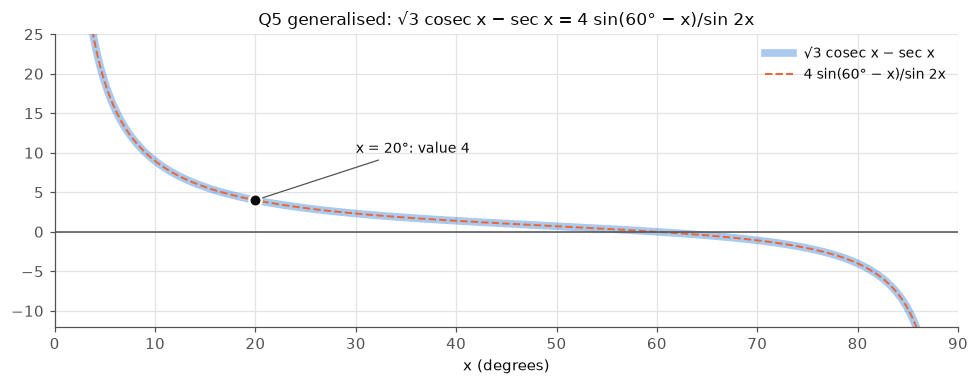

In [8]:
print(f"√3·cosec20° − sec20° = {np.sqrt(3)/np.sin(d(20)) - 1/np.cos(d(20)):.12f}")
x = np.linspace(2, 88, 2000); xr = d(x)
lhs = np.sqrt(3)/np.sin(xr) - 1/np.cos(xr)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(x, lhs, color=BLUE, lw=5, alpha=0.4, label="√3 cosec x − sec x")
ax.plot(x, 4*np.sin(d(60) - xr)/np.sin(2*xr), color=ORANGE, lw=1.3, ls="--", label="4 sin(60° − x)/sin 2x")
ax.plot(20, 4, "o", color=INK, ms=8, mec="white", mew=1.5, zorder=5)
ax.annotate("x = 20°: value 4", (20, 4), xytext=(30, 10), fontsize=9, arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
ax.axhline(0, color=INK2, lw=1); ax.set_ylim(-12, 25); ax.set_xlim(0, 90); ax.set_xlabel("x (degrees)")
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.set_title("Q5 generalised: √3 cosec x − sec x = 4 sin(60° − x)/sin 2x", fontsize=11)
plt.tight_layout(); plt.show()

---
## Homework from the Lecture

### H1. Prove $\sin 18^\circ = \dfrac{\sqrt5 - 1}{4}$
The lecturer will solve it next session, but try it first.

<details>
<summary>Hint / sketch (open after attempting)</summary>

Let $\theta = 18^\circ$, so $5\theta = 90^\circ$ and $2\theta = 90^\circ - 3\theta$. Then $\sin 2\theta = \cos 3\theta$:
$$2\sin\theta\cos\theta = 4\cos^3\theta - 3\cos\theta$$
Divide by $\cos\theta \neq 0$: $2\sin\theta = 4\cos^2\theta - 3 = 1 - 4\sin^2\theta$, which gives $4s^2 + 2s - 1 = 0$ with $s = \sin\theta$.
So $s = \frac{-2 \pm \sqrt{20}}{8} = \frac{-1 \pm \sqrt5}{4}$. Keep the positive root, since $18^\circ$ is in quadrant I.
</details>

### H2. A multiple-choice question
It was shown on screen, with answers to post as "A = Ahmedabad, B = Bhannat, C = Kolkata, D = Delhi". The lecturer hints that it uses a concept discussed in this class. **The question itself isn't recoverable from the captions**, so it is not reproduced here.

In [9]:
print(f"sin18° = {np.sin(d(18)):.12f},   (√5 − 1)/4 = {(np.sqrt(5) - 1)/4:.12f}")
roots = np.roots([4, 2, -1]); print("roots of 4s² + 2s − 1 = 0:", np.round(roots, 6), "→ keep the positive one")

sin18° = 0.309016994375,   (√5 − 1)/4 = 0.309016994375
roots of 4s² + 2s − 1 = 0: [-0.809017  0.309017] → keep the positive one


---
## Summary: Techniques Learned

| Technique | Where it appeared |
|---|---|
| $\sin(A-B)\sin(A+B) = \sin^2A - \sin^2B$, then a triple-angle formula | Q1 |
| C & D on sums, then **divide** the equations to isolate one half-angle | Q2 (i) |
| **Square and add** two equations: $\sin^2 + \cos^2 = 1$ appears, and $\cos(\theta - \phi)$ comes out | Q2 (ii), Q3 |
| $1 \pm \cos m = 2\cos^2\frac{m}{2}$ or $2\sin^2\frac{m}{2}$, and $\tan^2\frac{m}{2} = \frac{1 - \cos m}{1 + \cos m}$ | Q2, Q3 |
| **Doubling cosine product:** multiply by $2\sin(\text{smallest angle})$ and let $2\sin x\cos x = \sin 2x$ collapse it | Q4 |
| Rewrite angles with allied-angle rules so a pattern appears ($\cos\frac{7\pi}{15} = -\cos\frac{8\pi}{15}$) | Q4 |
| Convert $\sec/\csc$ to $\sin/\cos$, then multiply by 2 to create formulas in **both** the numerator and the denominator | Q5 |

**Results worth memorising (especially for JEE)**
- $\sin\alpha\sin(60^\circ - \alpha)\sin(60^\circ + \alpha) = \frac14\sin 3\alpha$, and similarly for $\cos$ (with $\frac14\cos 3\alpha$) and $\tan$ (with $\tan 3\alpha$)
- $\cos A\cos 2A\cdots\cos 2^{n-1}A = \dfrac{\sin 2^nA}{2^n\sin A}$
- $\sin 18^\circ = \frac{\sqrt5 - 1}{4}$

### Practice
1. Find $\cos 20^\circ\cos 40^\circ\cos 80^\circ$ using the doubling product. (Compare with Lecture 5's longer method.)
2. Find $\cos\frac{\pi}{7}\cos\frac{2\pi}{7}\cos\frac{4\pi}{7}$.
3. Prove $\tan 20^\circ\tan 40^\circ\tan 80^\circ = \sqrt3$, using Q1's $\tan$ sibling.
4. Prove $\csc 10^\circ - \sqrt3\sec 10^\circ = 4$.

In [10]:
c = lambda deg: np.cos(d(deg))
print(f"1. cos20·cos40·cos80 = {c(20)*c(40)*c(80):.10f}   = sin160°/(8 sin20°) = 1/8")
print(f"2. cos(π/7)cos(2π/7)cos(4π/7) = {np.cos(np.pi/7)*np.cos(2*np.pi/7)*np.cos(4*np.pi/7):.10f}   = −1/8")
print(f"3. tan20·tan40·tan80 = {np.tan(d(20))*np.tan(d(40))*np.tan(d(80)):.10f}   √3 = {np.sqrt(3):.10f}")
print(f"4. cosec10° − √3 sec10° = {1/np.sin(d(10)) - np.sqrt(3)/np.cos(d(10)):.10f}")

1. cos20·cos40·cos80 = 0.1250000000   = sin160°/(8 sin20°) = 1/8
2. cos(π/7)cos(2π/7)cos(4π/7) = -0.1250000000   = −1/8
3. tan20·tan40·tan80 = 1.7320508076   √3 = 1.7320508076
4. cosec10° − √3 sec10° = 4.0000000000
